# Mineração de Opiniões e Análise de Sentimentos

* Análise de Sentimentos baseada em Aspectos
* Fine-tuning do BERT



# Instalando e Importando Bibliotecas


In [ ]:
!pip install -U pip
!pip install ktrain
!pip install tensorflow
!pip install tf_keras
import os
os.environ['TF_USE_LEGACY_KERAS']="1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 67.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 34.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ktrain: filename=ktrain-0.41.4-py3-none-any.whl size=25316932 sha256=be4eed1018af710575999c086ac42bf716a73a04f3aa2ea8a06193335cfd1dea
  Stored in

### Pandas e Numpy

In [ ]:
import pandas as pd
import numpy as np

### ktrain
ktrain is a Python library that makes deep learning and AI more accessible and easier to apply

https://github.com/amaiya/ktrain

In [ ]:
import keras
import ktrain
from ktrain import text

### Sklearn

In [ ]:
from sklearn.metrics import classification_report

# Base Textual


https://alt.qcri.org/semeval2014/




In [ ]:
!gdown --id 1YDrmlFNFbV5ikI8Hzp36aDu--DLu94cv

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1YDrmlFNFbV5ikI8Hzp36aDu--DLu94cv
To: /content/laptop_train.csv
100% 289k/289k [00:00<00:00, 4.80MB/s]


In [ ]:
!gdown --id 1N1aFEkhcdz_T9H6pib-0rMwQRol5Ioy8

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1N1aFEkhcdz_T9H6pib-0rMwQRol5Ioy8
To: /content/laptop_test.csv
100% 67.0k/67.0k [00:00<00:00, 40.7MB/s]


In [ ]:
df_train = pd.read_csv('laptop_train.csv')
df_train

,review,aspect,sentiment
0,I charge it at night and skip taking the cord ...,cord,0
1,I charge it at night and skip taking the cord ...,battery life,1
2,The tech guy then said the service center does...,service center,-1
3,The tech guy then said the service center does...,"""sales"" team",-1
4,The tech guy then said the service center does...,tech guy,0
...,...,...,...
2323,We also use Paralles so we can run virtual mac...,Windows 7 Home Premium,0
2324,We also use Paralles so we can run virtual mac...,Windows Server Enterprise 2003,0
2325,We also use Paralles so we can run virtual mac...,Windows Server 2008 Enterprise,0
2326,"How Toshiba handles the repair seems to vary ,...",repair,1


In [ ]:
df_test = pd.read_csv('laptop_test.csv')
df_test

,review,aspect,sentiment
0,"Boot time is super fast , around anywhere from...",Boot time,1
1,tech support would not fix the problem unless ...,tech support,-1
2,Set up was easy .,Set up,1
3,Did not enjoy the new Windows 8 and touchscree...,Windows 8,-1
4,Did not enjoy the new Windows 8 and touchscree...,touchscreen functions,-1
...,...,...,...
633,I 've had it for about 2 months now and found ...,software,0
634,I 've had it for about 2 months now and found ...,updates,0
635,the latest version does not have a disc drive .,disc drive,0
636,Screen - although some people might complain a...,Screen,1


<Axes: >

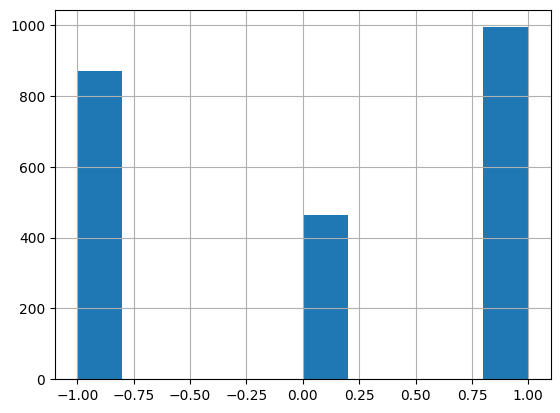

In [ ]:
df_train.sentiment.hist()

In [ ]:
list(df_train.aspect.unique())

['cord',
 'battery life',
 'service center',
 '"sales" team',
 'tech guy',
 'quality',
 'GUI',
 'applications',
 'use',
 'start up',
 'features',
 'iChat',
 'Photobooth',
 'garage band',
 'screen',
 'power light',
 'hard drive ligh',
 'processor',
 'graphics cards',
 'battery',
 'rubber enclosure',
 'edge',
 'multi-touch gestures',
 'tracking area',
 'external mouse',
 'gaming',
 'suite of software',
 'speed',
 'Windows 7',
 'usb devices',
 'software',
 'system',
 'Microsoft office for the mac',
 'syncing',
 '30" HD Monitor',
 'boot up',
 'service',
 'operating system',
 'preloaded software',
 'price',
 'clock in BIOS setup',
 'WARRANTY SERVICE',
 'brand',
 'warranty',
 'fan',
 'Customer Service number',
 'talking to a technician',
 'hard disc',
 'windows',
 'drivers',
 'Drivers',
 'BIOS update',
 'HP Technical Support',
 'browser',
 'keyboard',
 'virus scan',
 '9 punds',
 'program',
 'warrenty',
 'Toshiba Warranty',
 'Quality',
 'webcam',
 'value',
 'internet',
 'managing personal fil

### Pré-Processamento

In [ ]:
# treino
x_train = df_train[['review', 'aspect']].values
y_train = df_train['sentiment'].apply(str).values

# teste
x_test = df_test[['review', 'aspect']].values
y_test = df_test['sentiment'].apply(str).values


# O nosso input é formado por um par review-aspect (str, str)
x_train = list(map(tuple, x_train))
x_test = list(map(tuple, x_test))

In [ ]:
x_train

[('I charge it at night and skip taking the cord with me because of the good battery life .',
  'cord'),
 ('I charge it at night and skip taking the cord with me because of the good battery life .',
  'battery life'),
 ("The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the `` sales '' team , which is the retail shop which I bought my netbook from .",
  'service center'),
 ('The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the "sales" team , which is the retail shop which I bought my netbook from .',
  '"sales" team'),
 ("The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the `` sales '' team , which is the retail shop which I bought my netbook from .",
  'tech guy'),
 ('it is of high quality , has a killer GUI , is extremely stable , is highly expandable , is bundled with lots of very good applications , is easy to use , a

In [ ]:
y_train

array(['0', '1', '-1', ..., '0', '1', '0'], dtype=object)

In [ ]:
x_train

[('I charge it at night and skip taking the cord with me because of the good battery life .',
  'cord'),
 ('I charge it at night and skip taking the cord with me because of the good battery life .',
  'battery life'),
 ("The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the `` sales '' team , which is the retail shop which I bought my netbook from .",
  'service center'),
 ('The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the "sales" team , which is the retail shop which I bought my netbook from .',
  '"sales" team'),
 ("The tech guy then said the service center does not do 1-to-1 exchange and I have to direct my concern to the `` sales '' team , which is the retail shop which I bought my netbook from .",
  'tech guy'),
 ('it is of high quality , has a killer GUI , is extremely stable , is highly expandable , is bundled with lots of very good applications , is easy to use , a

In [ ]:
t = text.Transformer('bert-base-cased', maxlen=128)
trn = t.preprocess_train(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

preprocessing train...
language: en
sentence pairs detected


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Is Multi-Label? False


# Fine-tuning do BERT

In [ ]:
model = t.get_classifier()
classifier = ktrain.get_learner(model, train_data=trn)

In [ ]:
classifier.fit(0.00002, 2) # calibrar aqui

Epoch 1/2
73/73 [==============================] - 80s 768ms/step - loss: 0.8096 - accuracy: 0.6632
Epoch 2/2
73/73 [==============================] - 57s 782ms/step - loss: 0.5079 - accuracy: 0.8080


# Avaliando

In [ ]:
predictor = ktrain.get_predictor(classifier.model, t)

In [ ]:
y_pred = predictor.predict(df_test.review.to_list())

In [ ]:
y_true = df_test.sentiment.astype(str).to_list()

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

          -1       0.64      0.70      0.67       128
           0       0.75      0.45      0.56       169
           1       0.80      0.94      0.86       341

    accuracy                           0.76       638
   macro avg       0.73      0.69      0.70       638
weighted avg       0.76      0.76      0.74       638



Comparar com outros modelos nesse mesmo conjunto de dados:

https://paperswithcode.com/sota/aspect-based-sentiment-analysis-on-semeval?metric=Laptop%20(Acc)

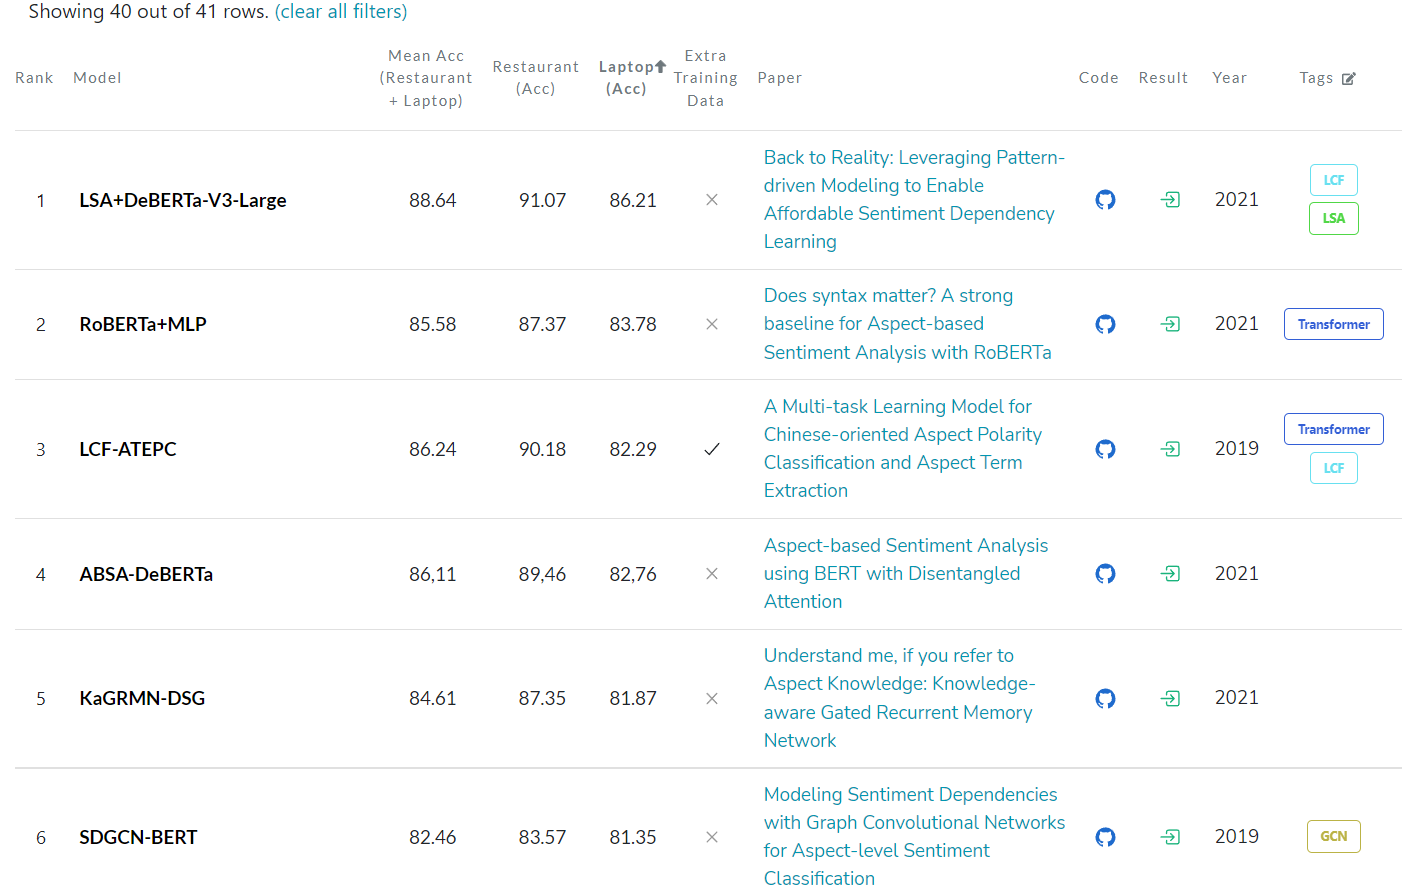

### Exemplos

In [ ]:
aspect = 'keyboard'
predictor.predict(('The keyboard is good, but the screen is bad!',aspect))

'-1'

In [ ]:
aspect = 'screen'
predictor.predict(('The keyboard is very good, but the screen is bad!',aspect))

'-1'

### Salvando o Modelo

In [ ]:
predictor.save('meu_classificador_bert2.model')

In [ ]:
predictor = ktrain.load_predictor('meu_classificador_bert2.model')

In [ ]:
# prompt: gerar outros exemplos de predict em ingles

aspect = 'battery life'
r = predictor.predict(('The battery life is amazing, but the price is too high.', aspect))
print(r)

aspect = 'price'
r = predictor.predict(('The battery life is amazing, but the price is too high.', aspect))
print(r)


-1
-1
